# Transaction Monitoring: Exploratory Analysis & Model Training

## Objectives

This notebook provides a comprehensive analysis of the **SAML-D Anti-Money Laundering (AML) dataset** and demonstrates the model training process for detecting suspicious transactions.

### Key Goals:
1. **Exploratory Data Analysis (EDA)**: Understand the dataset structure, feature distributions, and class imbalance
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and prepare data for modeling
3. **Model Training**: Train multiple classification models to detect suspicious transactions
4. **Model Evaluation**: Compare model performance using appropriate metrics for imbalanced datasets

### Dataset Overview:
- **Total Transactions**: 9,504,852
- **Features**: 12 (Time, Date, Sender_account, Receiver_account, Amount, Payment_currency, Received_currency, Sender_bank_location, Receiver_bank_location, Payment_type, Is_laundering, Laundering_type)
- **Typologies**: 28 (11 normal, 17 suspicious)
- **Class Imbalance**: Only 0.1039% of transactions are suspicious

---

## 1. Installation and Imports

In [1]:
# Install the TransactionMonitoring package
import sys
sys.path.append('..')

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Initial Exploration

In [2]:
# Load the transaction data
data_path = '../TMdata/transactiondata.csv'

# Load a sample for initial exploration (full dataset is very large)
df = pd.read_csv(data_path, nrows=100000)

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

Dataset Shape: (100000, 12)

Columns: ['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']

Data Types:
Time                       object
Date                       object
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency           object
Received_currency          object
Sender_bank_location       object
Receiver_bank_location     object
Payment_type               object
Is_laundering               int64
Laundering_type            object
dtype: object


In [3]:
# Display first few rows
df.head(10)

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,15:19:24,2023-03-30,2165441466,4740428686,10634.83,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_Out
1,11:46:07,2023-01-30,8727800527,4439365228,6061.23,UK pounds,UK pounds,UK,UK,Debit card,0,Normal_Fan_Out
2,14:49:55,2022-12-28,1846952352,1176621563,10799.44,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
3,13:17:16,2022-11-05,9645134398,554136849,22769.60,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Fan_In
4,09:11:38,2023-03-07,7920724755,5412335503,7860.89,UK pounds,Swiss franc,UK,Switzerland,Cross-border,0,Normal_Plus_Mutual
5,16:39:12,2022-11-07,9427828785,7988913223,376.75,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
6,17:10:02,2023-07-04,9371649648,9675690528,8816.63,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Fan_In
7,10:16:20,2023-06-20,5067270740,4926187145,5429.73,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out
8,11:50:52,2022-11-27,4060604088,2286018048,7328.85,UK pounds,Dirham,UK,Turkey,Cross-border,0,Normal_Fan_Out
9,23:42:05,2023-05-01,6492077591,7107443050,13431.85,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In


In [4]:
# Basic statistics
df.describe()

,Sender_account,Receiver_account,Amount,Is_laundering
count,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000
mean,5.003846e+09,4.998739e+09,8.848713e+03,0.001140
std,2.882948e+09,2.883019e+09,3.271940e+04,0.033745
min,5.867300e+04,1.326600e+04,5.360000e+00,0.000000
25%,2.517846e+09,2.509829e+09,2.155713e+03,0.000000
50%,5.002785e+09,4.990489e+09,6.127060e+03,0.000000
75%,7.495019e+09,7.497997e+09,1.047178e+04,0.000000
max,9.999706e+09,9.999337e+09,5.971169e+06,1.000000


In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found!")

Missing Values:
Series([], dtype: int64)

No missing values found!


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution (Class Imbalance)

Target Variable Distribution:

Counts:
Is_laundering
0    99886
1      114
Name: count, dtype: int64

Percentages:
Is_laundering
0    99.886
1     0.114
Name: proportion, dtype: float64


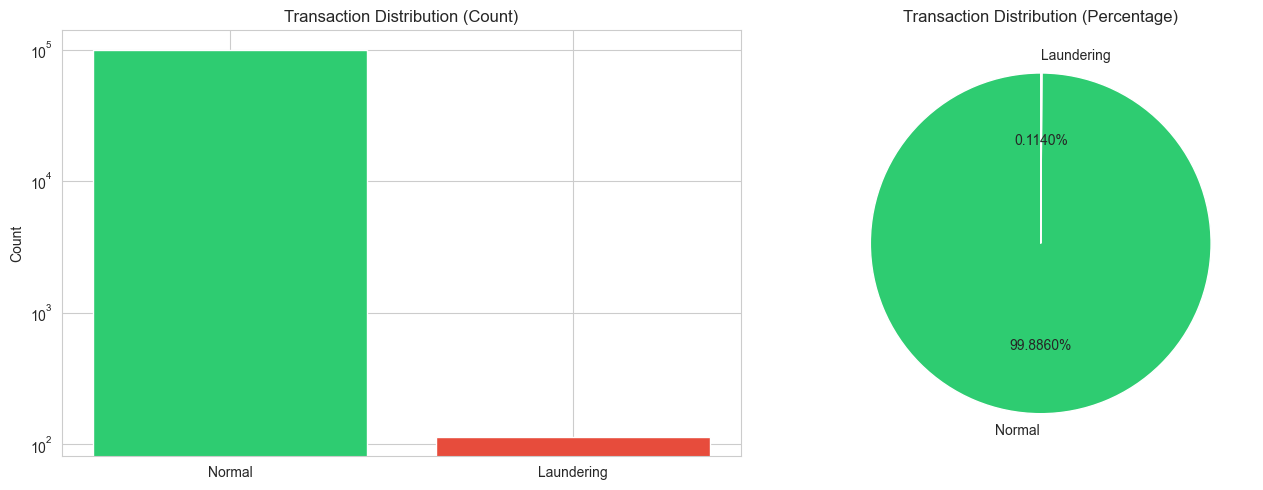


Imbalance Ratio: 1:876


In [6]:
# Analyze the target variable
target_col = 'Is_laundering'

target_counts = df[target_col].value_counts()
target_percentages = df[target_col].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"\nCounts:\n{target_counts}")
print(f"\nPercentages:\n{target_percentages}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Normal', 'Laundering'], target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Distribution (Count)')
axes[0].set_yscale('log')

# Pie chart
axes[1].pie(target_counts.values, labels=['Normal', 'Laundering'], 
            autopct='%1.4f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Transaction Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Calculate imbalance ratio
imbalance_ratio = target_counts.min() / target_counts.max()
print(f"\nImbalance Ratio: 1:{1/imbalance_ratio:.0f}")

### 3.2 Transaction Amount Analysis

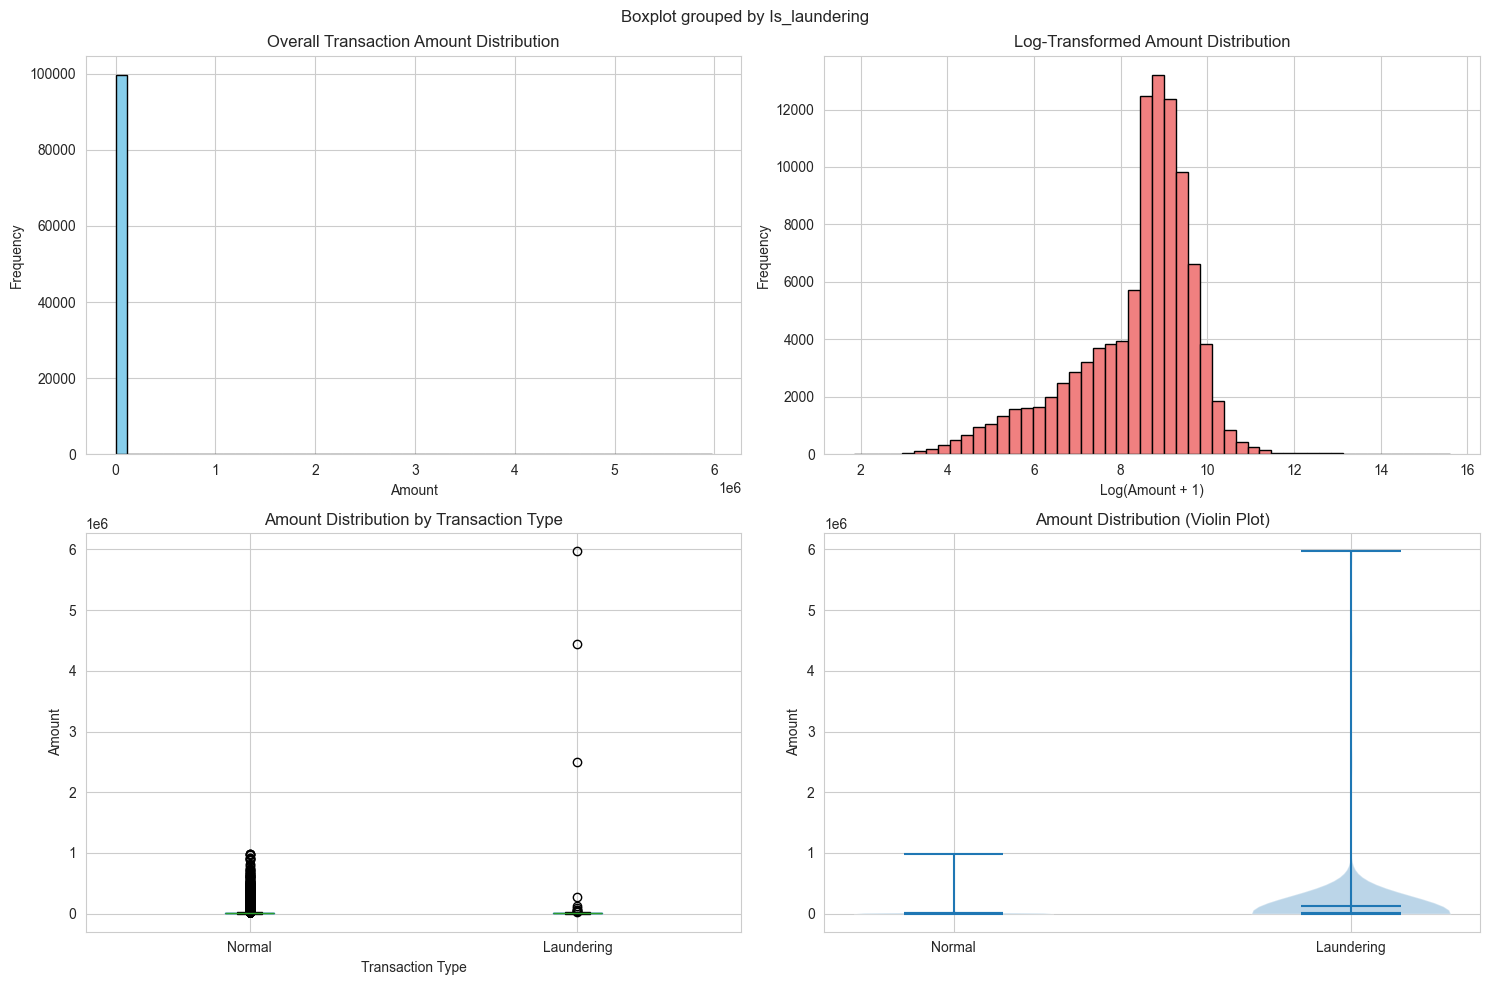


Amount Statistics by Transaction Type:
                 count           mean            std    min        25%  \
Is_laundering                                                            
0              99886.0    8715.804492   21366.449853   5.36  2155.0925   
1                114.0  125302.136567  728114.777041  30.22  2870.4225   

                    50%         75%         max  
Is_laundering                                    
0              6127.530  10471.8275   986174.47  
1              6027.365  10122.0950  5971168.57  


In [7]:
# Analyze transaction amounts
amount_col = 'Amount'

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall amount distribution
axes[0, 0].hist(df[amount_col], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Transaction Amount Distribution')

# Log-scale amount distribution
axes[0, 1].hist(np.log1p(df[amount_col]), bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Log(Amount + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Log-Transformed Amount Distribution')

# Amount by transaction type
df.boxplot(column=amount_col, by=target_col, ax=axes[1, 0])
axes[1, 0].set_xlabel('Transaction Type')
axes[1, 0].set_ylabel('Amount')
axes[1, 0].set_title('Amount Distribution by Transaction Type')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Normal', 'Laundering'])

# Violin plot
suspicious_mask = df[target_col] == 1
axes[1, 1].violinplot([df[~suspicious_mask][amount_col].values, 
                       df[suspicious_mask][amount_col].values],
                      showmeans=True, showmedians=True)
axes[1, 1].set_xticks([1, 2])
axes[1, 1].set_xticklabels(['Normal', 'Laundering'])
axes[1, 1].set_ylabel('Amount')
axes[1, 1].set_title('Amount Distribution (Violin Plot)')

plt.tight_layout()
plt.show()

print("\nAmount Statistics by Transaction Type:")
print(df.groupby(target_col)[amount_col].describe())

### 3.3 Temporal Analysis

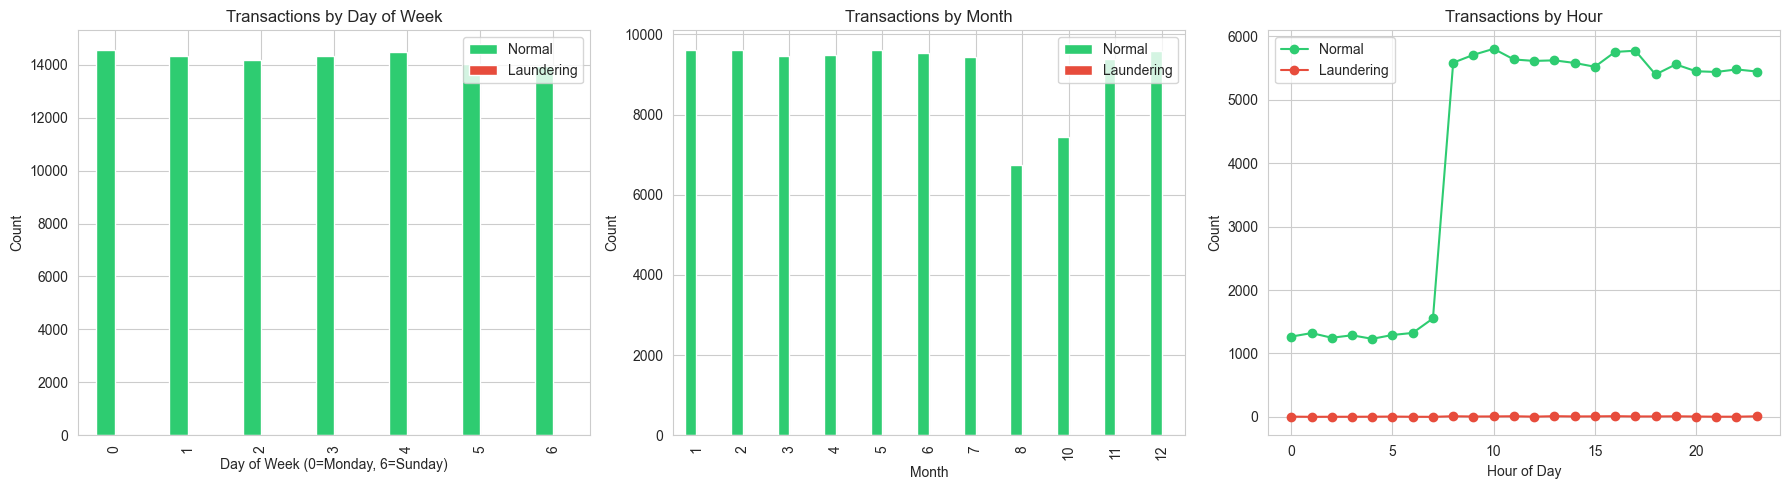

In [8]:
# Temporal analysis
time_col = 'Time'
date_col = 'Date'

# Convert to datetime
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Extract temporal features
df['day_of_week'] = df[date_col].dt.dayofweek
df['month'] = df[date_col].dt.month
df['hour'] = pd.to_datetime(df[time_col], format='%H:%M:%S', errors='coerce').dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transactions by day of week
day_counts = df.groupby(['day_of_week', target_col]).size().unstack(fill_value=0)
day_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[0].set_ylabel('Count')
axes[0].set_title('Transactions by Day of Week')
axes[0].legend(['Normal', 'Laundering'])

# Transactions by month
month_counts = df.groupby(['month', target_col]).size().unstack(fill_value=0)
month_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_title('Transactions by Month')
axes[1].legend(['Normal', 'Laundering'])

# Transactions by hour
hour_counts = df.groupby(['hour', target_col]).size().unstack(fill_value=0)
hour_counts.plot(kind='line', ax=axes[2], color=['#2ecc71', '#e74c3c'], marker='o')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Count')
axes[2].set_title('Transactions by Hour')
axes[2].legend(['Normal', 'Laundering'])

plt.tight_layout()
plt.show()

### 3.4 Payment Type and Currency Analysis

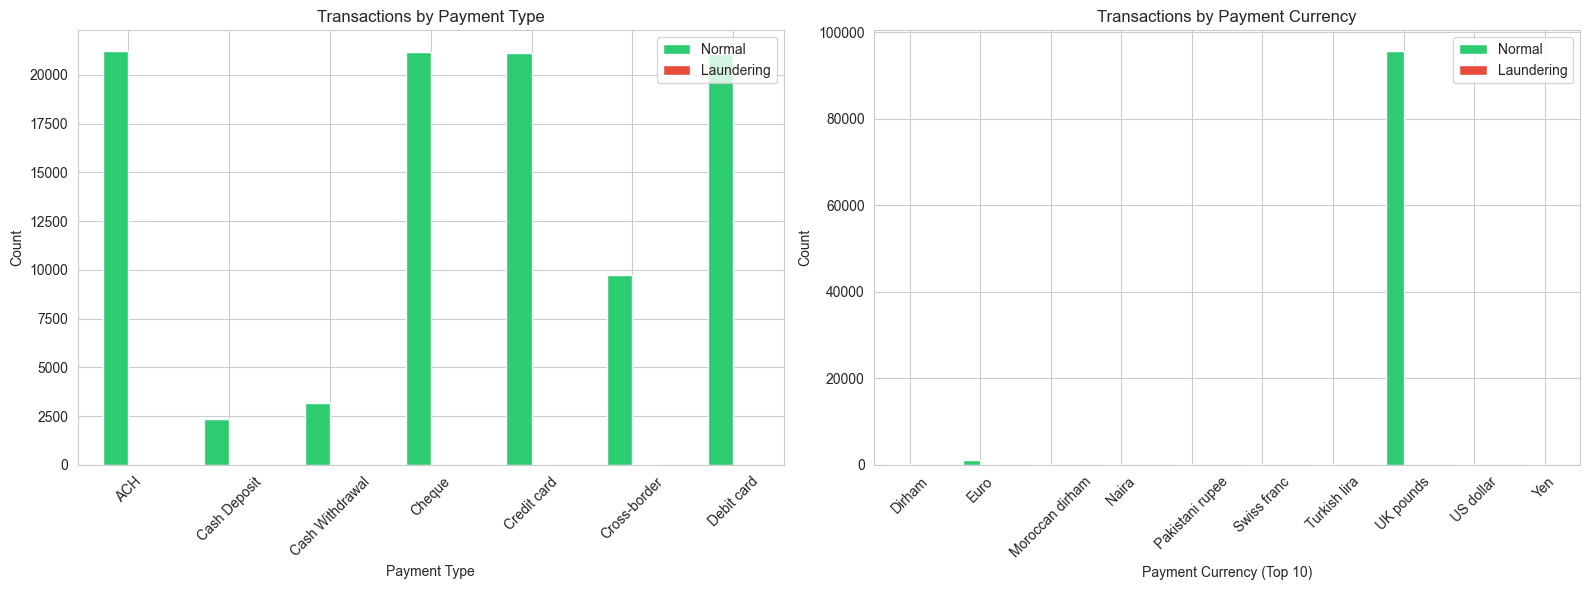


Laundering Rate by Payment Type:
Payment_type
Cash Withdrawal    0.651365
Cash Deposit       0.505902
Cross-border       0.276951
ACH                0.089466
Debit card         0.080695
Credit card        0.052012
Cheque             0.033016
Name: Is_laundering, dtype: float64


In [9]:
# Payment type analysis
payment_col = 'Payment_type'
payment_currency_col = 'Payment_currency'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Payment type distribution
payment_counts = df.groupby([payment_col, target_col]).size().unstack(fill_value=0)
payment_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Transactions by Payment Type')
axes[0].legend(['Normal', 'Laundering'])
axes[0].tick_params(axis='x', rotation=45)

# Payment currency distribution (top 10)
top_currencies = df[payment_currency_col].value_counts().head(10).index
currency_data = df[df[payment_currency_col].isin(top_currencies)]
currency_counts = currency_data.groupby([payment_currency_col, target_col]).size().unstack(fill_value=0)
currency_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Payment Currency (Top 10)')
axes[1].set_ylabel('Count')
axes[1].set_title('Transactions by Payment Currency')
axes[1].legend(['Normal', 'Laundering'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nLaundering Rate by Payment Type:")
print(df.groupby(payment_col)[target_col].mean().sort_values(ascending=False) * 100)

### 3.5 Geographic Analysis (Bank Locations)

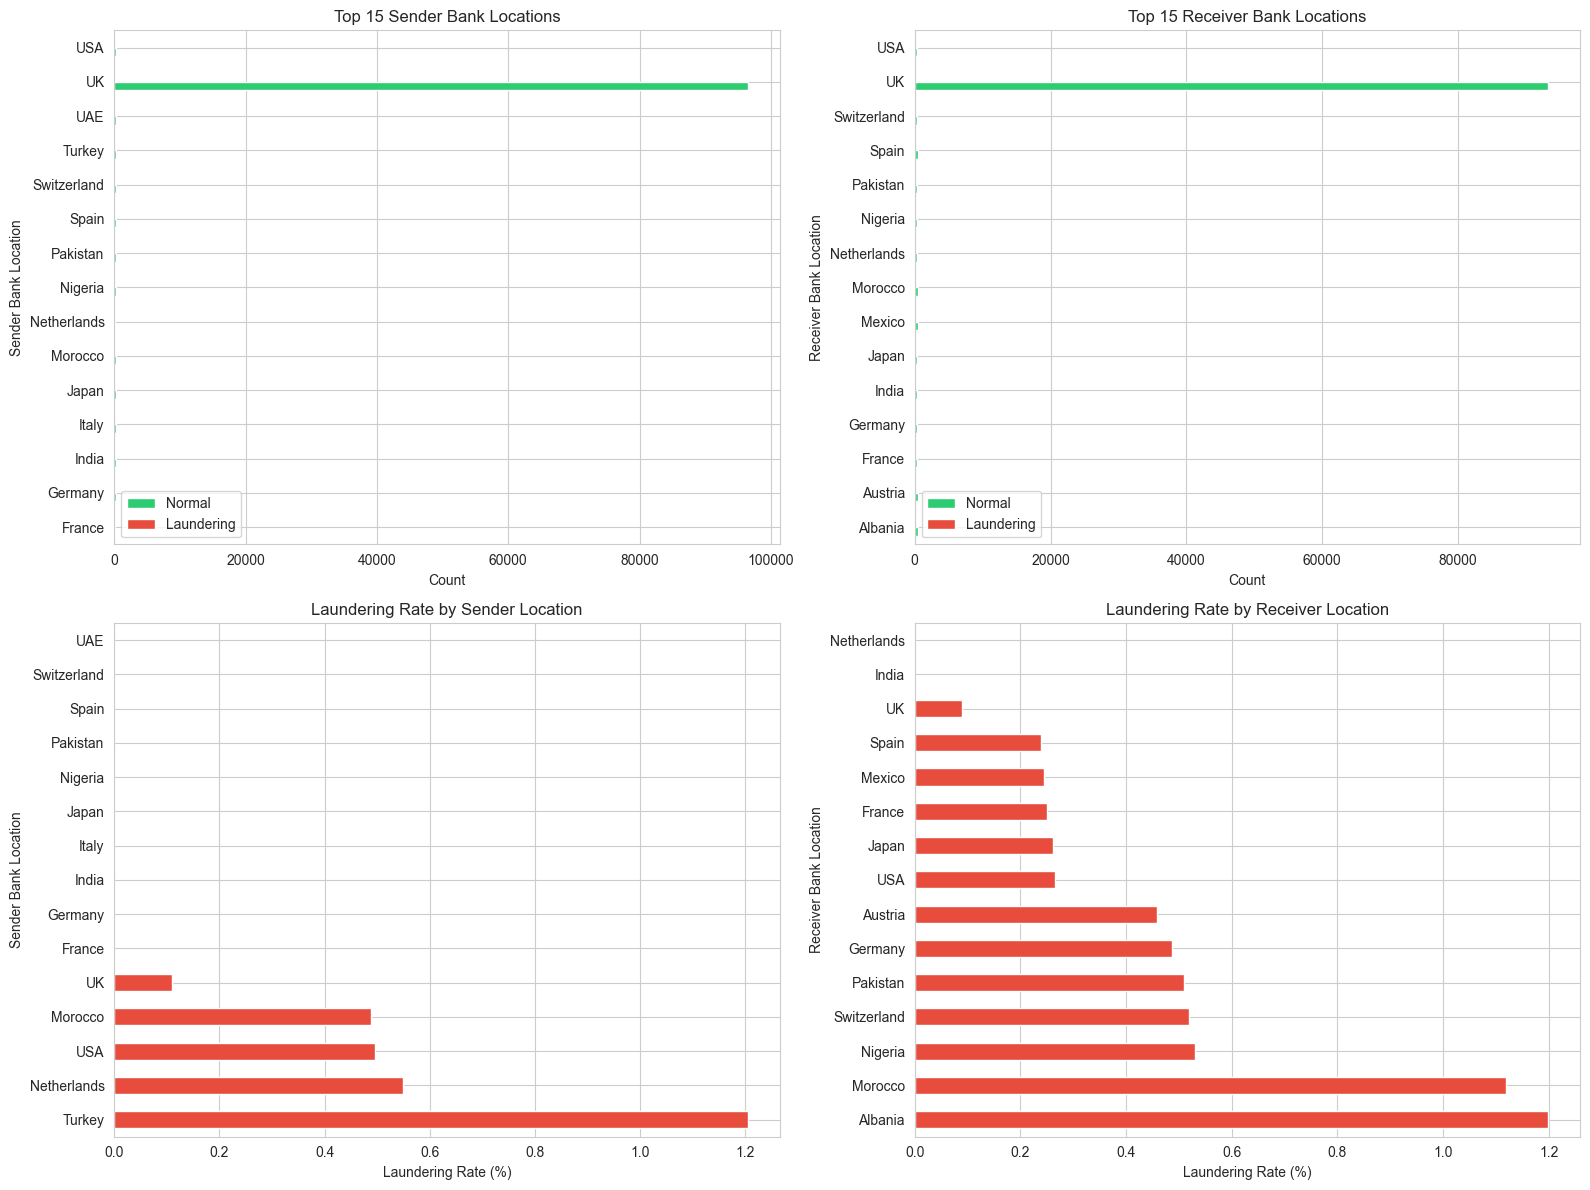

In [10]:
# Bank location analysis
sender_bank_col = 'Sender_bank_location'
receiver_bank_col = 'Receiver_bank_location'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top sender bank locations
top_sender_banks = df[sender_bank_col].value_counts().head(15).index
sender_data = df[df[sender_bank_col].isin(top_sender_banks)]
sender_counts = sender_data.groupby([sender_bank_col, target_col]).size().unstack(fill_value=0)
sender_counts.plot(kind='barh', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Sender Bank Location')
axes[0, 0].set_title('Top 15 Sender Bank Locations')
axes[0, 0].legend(['Normal', 'Laundering'])

# Top receiver bank locations
top_receiver_banks = df[receiver_bank_col].value_counts().head(15).index
receiver_data = df[df[receiver_bank_col].isin(top_receiver_banks)]
receiver_counts = receiver_data.groupby([receiver_bank_col, target_col]).size().unstack(fill_value=0)
receiver_counts.plot(kind='barh', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Receiver Bank Location')
axes[0, 1].set_title('Top 15 Receiver Bank Locations')
axes[0, 1].legend(['Normal', 'Laundering'])

# Laundering rate by sender location
sender_susp_rate = sender_data.groupby(sender_bank_col)[target_col].mean().sort_values(ascending=False) * 100
sender_susp_rate.plot(kind='barh', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Laundering Rate (%)')
axes[1, 0].set_ylabel('Sender Bank Location')
axes[1, 0].set_title('Laundering Rate by Sender Location')

# Laundering rate by receiver location
receiver_susp_rate = receiver_data.groupby(receiver_bank_col)[target_col].mean().sort_values(ascending=False) * 100
receiver_susp_rate.plot(kind='barh', ax=axes[1, 1], color='#e74c3c')
axes[1, 1].set_xlabel('Laundering Rate (%)')
axes[1, 1].set_ylabel('Receiver Bank Location')
axes[1, 1].set_title('Laundering Rate by Receiver Location')

plt.tight_layout()
plt.show()

### 3.6 Laundering Type Analysis

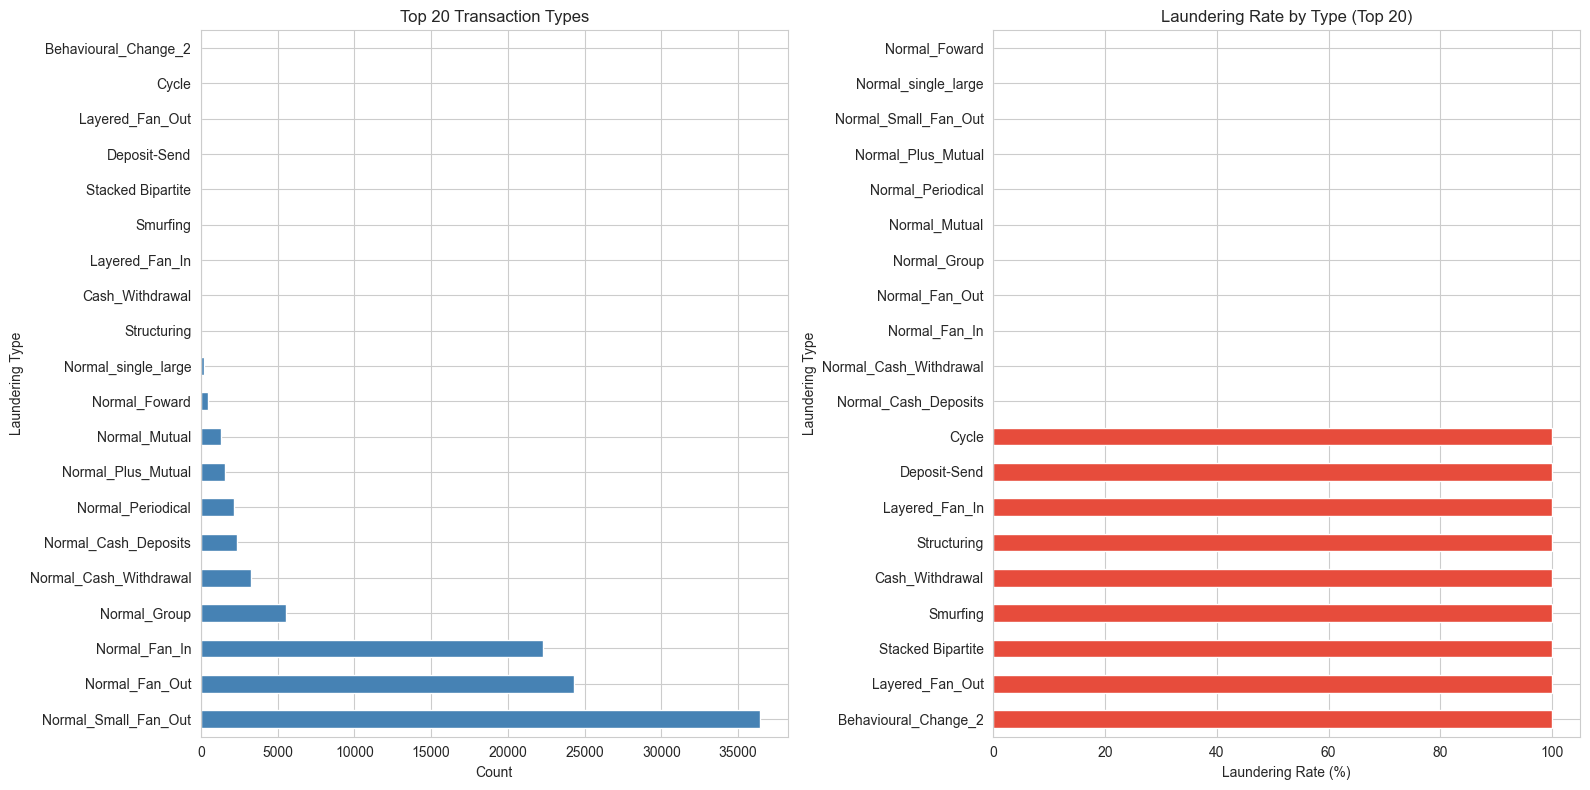


Laundering Type Statistics:
Total unique types: 27

Top 10 most common types:
Laundering_type
Normal_Small_Fan_Out      36392
Normal_Fan_Out            24296
Normal_Fan_In             22292
Normal_Group               5525
Normal_Cash_Withdrawal     3266
Normal_Cash_Deposits       2360
Normal_Periodical          2179
Normal_Plus_Mutual         1600
Normal_Mutual              1292
Normal_Foward               455
Name: count, dtype: int64


In [11]:
# Laundering type analysis
type_col = 'Laundering_type'

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Typology distribution
type_counts = df[type_col].value_counts().head(20)
type_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Laundering Type')
axes[0].set_title('Top 20 Transaction Types')

# Laundering rate by typology
top_types = df[type_col].value_counts().head(20).index
type_data = df[df[type_col].isin(top_types)]
type_rate = type_data.groupby(type_col)[target_col].mean().sort_values(ascending=False) * 100
type_rate.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_xlabel('Laundering Rate (%)')
axes[1].set_ylabel('Laundering Type')
axes[1].set_title('Laundering Rate by Type (Top 20)')

plt.tight_layout()
plt.show()

print("\nLaundering Type Statistics:")
print(f"Total unique types: {df[type_col].nunique()}")
print(f"\nTop 10 most common types:")
print(df[type_col].value_counts().head(10))

### 3.7 Correlation Analysis

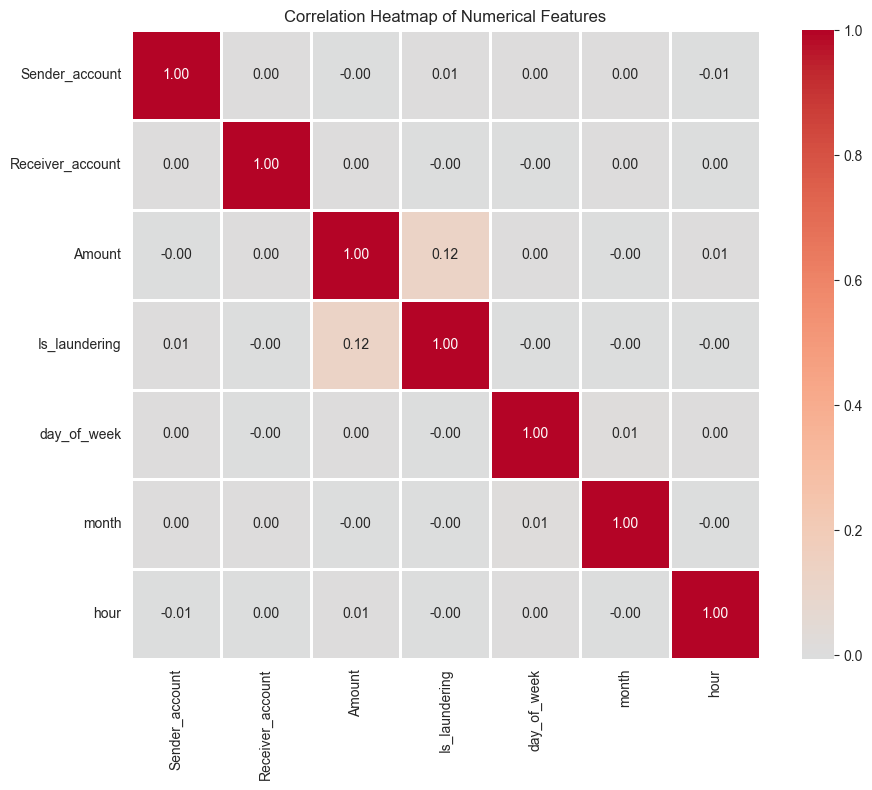


Features most correlated with laundering:
Amount              0.120240
Sender_account      0.005301
hour               -0.002881
day_of_week        -0.003338
Receiver_account   -0.003775
month              -0.003796
Name: Is_laundering, dtype: float64


In [12]:
# Correlation heatmap
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

print("\nFeatures most correlated with laundering:")
target_corr = correlation_matrix[target_col].sort_values(ascending=False)
print(target_corr.drop(target_col))

## 4. Data Preprocessing for Model Training

### 4.1 Load Larger Sample

In [13]:
# Load larger sample for training
print("Loading data for model training...")
df_model = pd.read_csv(data_path, nrows=500000)

print(f"Training dataset shape: {df_model.shape}")
print(f"Laundering transactions: {df_model[target_col].sum()} ({df_model[target_col].mean()*100:.4f}%)")

Loading data for model training...
Training dataset shape: (486648, 12)
Laundering transactions: 484 (0.0995%)


### 4.2 Feature Engineering

In [14]:
# Feature engineering
print("Engineering features...")

# Temporal features
df_model[date_col] = pd.to_datetime(df_model[date_col], errors='coerce')
df_model['day_of_week'] = df_model[date_col].dt.dayofweek
df_model['month'] = df_model[date_col].dt.month
df_model['day'] = df_model[date_col].dt.day
df_model['is_weekend'] = (df_model['day_of_week'] >= 5).astype(int)

# Time features
df_model['hour'] = pd.to_datetime(df_model[time_col], format='%H:%M:%S', errors='coerce').dt.hour
df_model['is_night'] = ((df_model['hour'] >= 22) | (df_model['hour'] <= 6)).astype(int)

# Currency mismatch
df_model['currency_mismatch'] = (df_model['Payment_currency'] != df_model['Received_currency']).astype(int)

# Cross-border transaction
df_model['cross_border'] = (df_model['Sender_bank_location'] != df_model['Receiver_bank_location']).astype(int)

# Amount features
df_model['log_amount'] = np.log1p(df_model[amount_col])
df_model['amount_squared'] = df_model[amount_col] ** 2

print(f"New shape: {df_model.shape}")

Engineering features...
New shape: (486648, 22)


### 4.3 Prepare Features and Target

In [15]:
# Separate features and target
X = df_model.drop(columns=[target_col, 'Laundering_type', date_col, time_col, 
                           'Sender_account', 'Receiver_account'], errors='ignore')
y = df_model[target_col]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

Feature matrix shape: (486648, 16)
Target shape: (486648,)

Features: ['Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'day_of_week', 'month', 'day', 'is_weekend', 'hour', 'is_night', 'currency_mismatch', 'cross_border', 'log_amount', 'amount_squared']


### 4.4 Encode Categorical Variables

In [16]:
# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols_X}")

label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("\nEncoding completed!")

Categorical columns: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
Numerical columns: ['Amount', 'day_of_week', 'month', 'day', 'is_weekend', 'hour', 'is_night', 'currency_mismatch', 'cross_border', 'log_amount', 'amount_squared']

Encoding completed!


### 4.5 Train-Test Split

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nTest class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (389318, 16)
Test set: (97330, 16)

Training class distribution:
Is_laundering
0    99.900595
1     0.099405
Name: proportion, dtype: float64

Test class distribution:
Is_laundering
0    99.900339
1     0.099661
Name: proportion, dtype: float64


### 4.6 Feature Scaling

In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numerical_features = [col for col in numerical_cols_X if col in X_train.columns]

if numerical_features:
    X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
    X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
    print("Scaling completed!")

Scaling completed!


## 5. Model Training and Evaluation

### 5.1 Define Models

In [19]:
# Define models
models = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {'n_estimators': [50, 100], 'max_depth': [10, 20]}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'params': {'criterion': ['gini', 'entropy'], 'max_depth': [10, 20]}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
        'params': {'C': [0.1, 1.0, 10.0]}
    }
}

print(f"Models to train: {len(models)}")

Models to train: 4


### 5.2 Train Models

In [ ]:
# Train models
results = {}
best_models = {}

print("Training models...\n")

for name, config in models.items():
    print(f"\nTraining {name}...")
    
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    
    results[name] = {
        'best_params': grid_search.best_params_,
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train, y_train_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        'train_recall': recall_score(y_train, y_train_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        'y_test_pred': y_test_pred
    }
    
    print(f"Best params: {grid_search.best_params_}")
    print(f"Test F1: {results[name]['test_f1']:.4f}")

print("\nTraining completed!")

### 5.3 Model Comparison

In [ ]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train F1': [results[m]['train_f1'] for m in results.keys()],
    'Test F1': [results[m]['test_f1'] for m in results.keys()],
    'Train Precision': [results[m]['train_precision'] for m in results.keys()],
    'Test Precision': [results[m]['test_precision'] for m in results.keys()],
    'Train Recall': [results[m]['train_recall'] for m in results.keys()],
    'Test Recall': [results[m]['test_recall'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test F1', ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['F1', 'Precision', 'Recall']
for idx, metric in enumerate(metrics):
    comparison_df.plot(x='Model', y=[f'Train {metric}', f'Test {metric}'], 
                       kind='bar', ax=axes[idx], rot=45)
    axes[idx].set_title(f'{metric} Score')
    axes[idx].set_ylabel(metric)
    axes[idx].set_ylim([0, 1])

plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")
print(f"Test F1: {comparison_df.iloc[0]['Test F1']:.4f}")

### 5.4 Best Model Evaluation

In [ ]:
# Evaluate best model
best_model = best_models[best_model_name]
y_test_pred = results[best_model_name]['y_test_pred']

print(f"Classification Report for {best_model_name}:")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Laundering']))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Laundering'],
            yticklabels=['Normal', 'Laundering'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(f"\nTrue Negatives: {cm_norm[0,0]*100:.2f}%")
print(f"False Positives: {cm_norm[0,1]*100:.2f}%")
print(f"False Negatives: {cm_norm[1,0]*100:.2f}%")
print(f"True Positives: {cm_norm[1,1]*100:.2f}%")

### 5.5 ROC Curves

In [ ]:
# ROC curves
plt.figure(figsize=(10, 8))

for name in results.keys():
    model = best_models[name]
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 Feature Importance

In [ ]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'Feature': X_train_scaled.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_20 = feat_imp.head(20)
    plt.barh(range(len(top_20)), top_20['Importance'].values)
    plt.yticks(range(len(top_20)), top_20['Feature'].values)
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nTop 20 Features:")
    print(feat_imp.head(20).to_string(index=False))
else:
    print(f"{best_model_name} doesn't support feature importance")

## 6. Summary

In [ ]:
print("="*60)
print("TRANSACTION MONITORING ANALYSIS SUMMARY")
print("="*60)
print(f"\n1. DATASET: {len(df_model):,} transactions")
print(f"   Laundering: {df_model[target_col].sum():,} ({df_model[target_col].mean()*100:.4f}%)")
print(f"   Features: {X_train_scaled.shape[1]}")
print(f"\n2. BEST MODEL: {best_model_name}")
print(f"   F1: {results[best_model_name]['test_f1']:.4f}")
print(f"   Precision: {results[best_model_name]['test_precision']:.4f}")
print(f"   Recall: {results[best_model_name]['test_recall']:.4f}")
print(f"\n3. ALL MODELS:")
for idx, row in comparison_df.iterrows():
    print(f"   {row['Model']:20s}: F1={row['Test F1']:.4f}")
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)